# Data Cleaning and EDA

loading the scraped data 

In [339]:
import pandas as pd


df = pd.read_csv("../data/raw/jiji_smartphones_raw.csv")

df.head()

,Title,Brand,Storage,Condition,Location,Price,RawPrice,Page
0,New Apple iPhone 14 256 GB Blue,iPhone,256GB,New,"Addis Ababa, Bole",79500,"ETB 79,500",1
1,Samsung Galaxy S23 Ultra 512 GB Black,Samsung,512GB,New,"Addis Ababa, Nifas Silk-Lafto",85000,"ETB 85,000",1
2,New Apple iPhone 14 Plus 128 GB Purple,iPhone,128GB,New,"Addis Ababa, Bole",78500,"ETB 78,500",1
3,New Apple iPhone 15 Pro 256 GB Blue,iPhone,256GB,New,"Addis Ababa, Bole",121000,"ETB 121,000",1
4,Apple iPhone 14 Pro Max 512 GB Black,iPhone,512GB,Used,"Addis Ababa, Bole",110500,"ETB 110,500",1


## Exploration

By printing shape, info, describe trying to understand number of rows and column of extracted data, the count and data type of extracted features and count for intiger data type features 

In [340]:
print(df.shape)
print(df.info())
print(df.describe())

(576, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      576 non-null    object
 1   Brand      576 non-null    object
 2   Storage    568 non-null    object
 3   Condition  576 non-null    object
 4   Location   576 non-null    object
 5   Price      576 non-null    int64 
 6   RawPrice   576 non-null    object
 7   Page       576 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 36.1+ KB
None
               Price        Page
count     576.000000  576.000000
mean    94050.088542   12.500000
std     42653.961089    6.928203
min     34500.000000    1.000000
25%     63874.250000    6.750000
50%     84999.500000   12.500000
75%    112249.750000   18.250000
max    260000.000000   24.000000


## Cheking for missing values

In [341]:
df.isnull().sum()

Title        0
Brand        0
Storage      8
Condition    0
Location     0
Price        0
RawPrice     0
Page         0
dtype: int64

 There is missing value in the **'Storage'** column contained null entries for 8 records (<1.5% of the total dataset). Given the low volume of missingness and the high sensitivity of the Storage feature relative to Price, listwise deletion is going to be performed to maintain data quality and prevent the introduction of synthetic bias through imputation.

In [342]:
df= df.dropna(subset=[ 'Storage'])
df.isnull().sum()

Title        0
Brand        0
Storage      0
Condition    0
Location     0
Price        0
RawPrice     0
Page         0
dtype: int64

## ckeking for duplicates 

In [343]:
print(df.duplicated().sum())

3


There is 3 duplicated values so we will remove them since having them cause **"data leakage"** where analysis or machine learning model becomes overconfident because it’s seeing the exact same information multiple times.

In [344]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


### converting Storage to numeric value

In [345]:
df["Storage"] = df["Storage"].str.extract(r'(\d+)')
df["Storage"] = pd.to_numeric(df["Storage"], errors='coerce')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 565 entries, 0 to 575
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      565 non-null    object
 1   Brand      565 non-null    object
 2   Storage    565 non-null    int64 
 3   Condition  565 non-null    object
 4   Location   565 non-null    object
 5   Price      565 non-null    int64 
 6   RawPrice   565 non-null    object
 7   Page       565 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 39.7+ KB
None


Storage was treated as a numerical feature rather than using one-hot encoding as it represents an ordered variable where higher values correspond to increased storage capacity and typically higher prices.

## Removing unnecessary columns

In [346]:
df = df.drop(columns=["RawPrice", "Page"])
print(df.head())

                                    Title    Brand  Storage Condition  \
0         New Apple iPhone 14 256 GB Blue   iPhone      256       New   
1   Samsung Galaxy S23 Ultra 512 GB Black  Samsung      512       New   
2  New Apple iPhone 14 Plus 128 GB Purple   iPhone      128       New   
3     New Apple iPhone 15 Pro 256 GB Blue   iPhone      256       New   
4    Apple iPhone 14 Pro Max 512 GB Black   iPhone      512      Used   

                        Location   Price  
0              Addis Ababa, Bole   79500  
1  Addis Ababa, Nifas Silk-Lafto   85000  
2              Addis Ababa, Bole   78500  
3              Addis Ababa, Bole  121000  
4              Addis Ababa, Bole  110500  


## EDA (Exploratory Data Analysis)

### 1 Univariate Analysis

#### Price Distribution

(array([ 75., 172., 161.,  49.,  45.,  22.,  25.,   4.,   2.,  10.]),
 array([ 34500.,  57050.,  79600., 102150., 124700., 147250., 169800.,
        192350., 214900., 237450., 260000.]),
 <BarContainer object of 10 artists>)

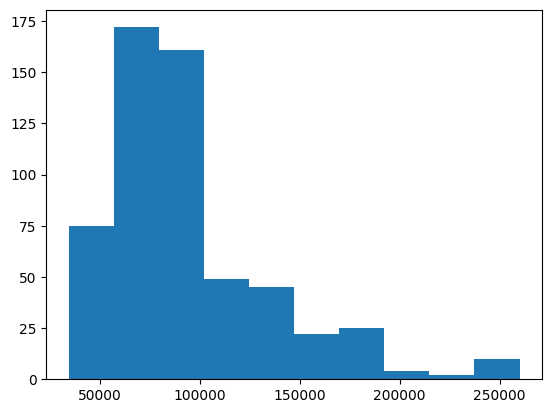

In [347]:
import matplotlib.pyplot as plt
plt.hist(df["Price"])

The distribution is right-skewed, with a concentration of items in the 60k–100k range and a sparse "premium" tail extending to 250k.

- Action for Regression: Because of the skew, I will apply a Log Transformation to the target variable to help the model handle the high-price outliers more effectively.

- Action for Classification: To ensure balanced classes for "Affordable" vs. "Expensive," I will use the Median (50th percentile) as the threshold. This prevents the model from being biased toward the majority "Affordable" group.

#### Storage Distribution

<Axes: >

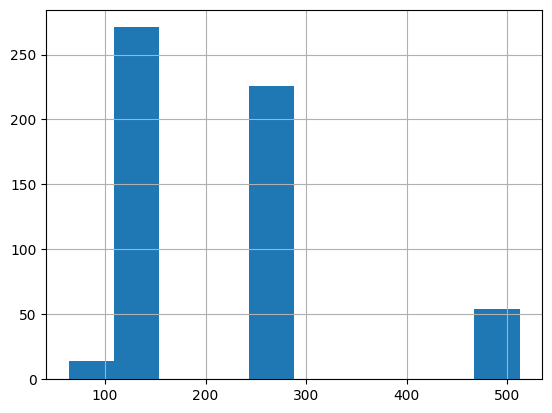

In [348]:
df["Storage"].hist()

The storage shows a multimodal distribution with four distinct spikes.

 - Primary Peak (128GB): Over 250 observations, representing the most common storage capacity in the market.

 - Secondary Peak (256GB): Over 200 observations, indicating a strong mid-to-high tier presence.

 - Sparse Tiers: 64GB and 512GB represent the extreme ends of the spectrum with significantly lower frequency.

Modeling Plan: 
  - for Regression: Because the storage values follow a clear mathematical order (64<128<256<512), keeping them numeric is ideal. The model can now calculate the exact "Price per GB" increase.

 - Scaling: During modeling, I will apply Standard Scaling or Min-Max Scaling to this feature so its large values (like 512) don't overpower binary features (like 0 or 1 for Brand).

#### Brand Frequency

<Axes: xlabel='Brand'>

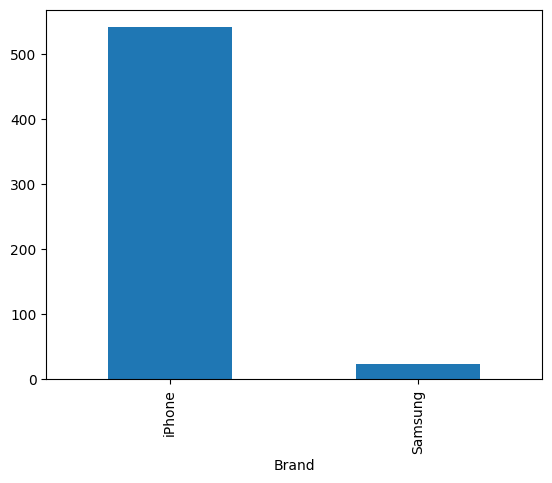

In [349]:
df["Brand"].value_counts().plot(kind='bar')

from Brand Distribution

- The dataset shows an imbalance in brand distribution with iPhone making up ~95% of the dataset and Samsung only ~5% compared to other brands such as Samsung. This reflects real-world marketplace trends.

### 2 Bivariate Analysis

#### Storage vs Price

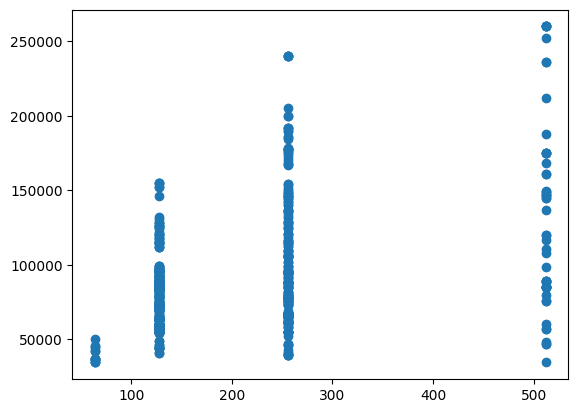

In [350]:
plt.scatter(df["Storage"], df["Price"])

from Storage and Brand Correlation: There is a clear positive correlation between storage capacity and price ceilings.

- Overlap Analysis: Significant overlap exists in the middle-price brackets across 128GB, 256GB, and 512GB tiers. This suggests that Brand or other features (like Condition) act as confounding variables that also heavily influence price.

- Feature Utility: Storage is a "strong predictor" because it effectively sets the price boundaries especially for the 64GB and 512GB segments.

#### Condition vs Price

<Axes: title={'center': 'Price'}, xlabel='Condition'>

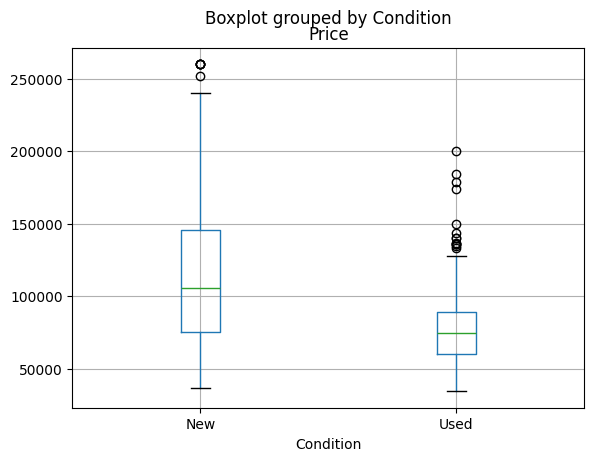

In [351]:
df.boxplot(column="Price", by="Condition")

from condition and price box plot observed Storage shows a strong relationship with price”. The median price for "New" devices is significantly higher than for "Used" devices.

- Variance Analysis: The "New" category shows higher price volatility (larger IQR) likely due to the inclusion of various models and storage tiers.

- Outlier Significance: The presence of high-price outliers in the "Used" category suggests that Brand and Storage can sometimes override the price-depressing effect of being used. I will not remove these outliers as they represent valid "Premium" market segments.

- Strategy: To mitigate their impact on the regression model I will use a Log Transformation on the target variable. For classification, these outliers will be naturally handled by the "Expensive" binary binning.



#### Brand vs Price

<Axes: xlabel='Brand'>

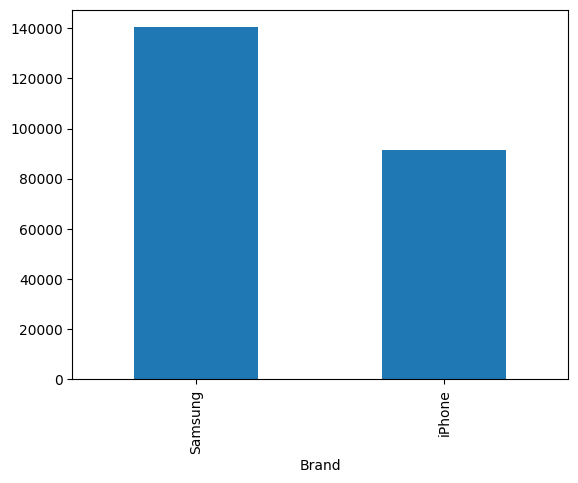

In [352]:
df.groupby("Brand")["Price"].mean().plot(kind='bar')

from brand and price observed: While iPhones dominate in volume, Samsung holds a higher average price point in this specific dataset.

- Outlier Justification: The outliers seen in the Price Histogram are likely high-end flagships from both brands. Deleting them would remove the "Premium" signal from the model.

- Decision: I will keep the outliers. To minimize their impact on the Regression model, I will use Log Transformation. This converts the "distance" between 100k and 250k into a smaller mathematical range that the model can handle without being "distracted" by the high numbers.

### 3 Multivariate

#### Correlation Heatmap

<Axes: >

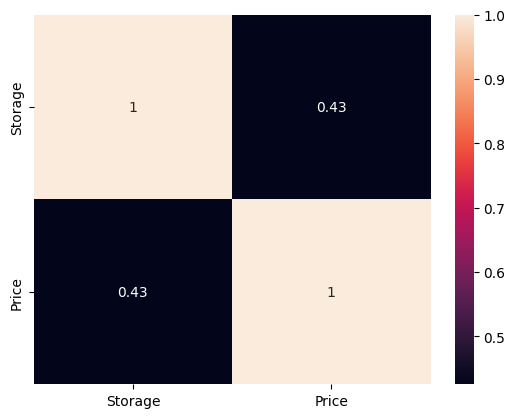

In [353]:
import seaborn as sns

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)

There is a moderate positive correlation (r=0.43) between Storage and Price.

- Interpretation: While storage is a significant factor in pricing it only explains a portion of the variance. This confirms the need for a Multivariate Model (using Brand and Condition simultaneously) rather than a simple linear model based on storage alone.

- Multicollinearity Check: Since this is our first heatmap, we only see two variables. As I add encoded features (like is_new) I will check this matrix again to ensure no two features are too similar (which can confuse the model).

### Outlier detection 

{'whiskers': [<matplotlib.lines.Line2D at 0x7b4c723253a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7b4c723259a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b4c72324560>],
 'medians': [<matplotlib.lines.Line2D at 0x7b4c72325e80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b4c72326120>],
 'means': []}

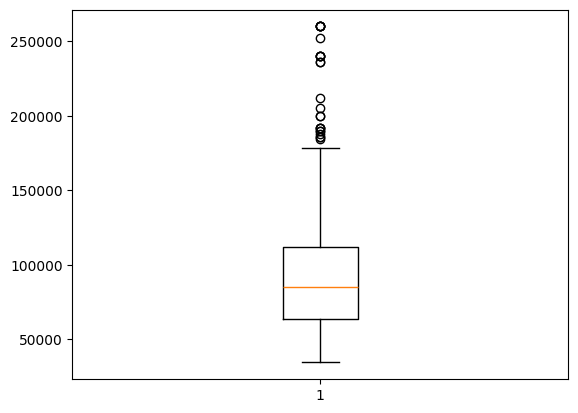

In [354]:
plt.boxplot(df["Price"])

- Median Price: The center orange line is approximately 85,000, representing the "typical" price for the phones in this dataset.

- Market Concentration (IQR): The box (middle 50% of data) is tightly packed between ~65,000 and ~115,000, showing that most phones compete in this specific price bracket.

- Premium Outliers: There is a significant number of outliers above 180,000, with the most expensive devices reaching over 250,000. These are likely the high-end flagship models (e.g., iPhone Pro Max or Samsung Ultra series).

- Outlier Strategy: I will keep the outliers because they represent real, high-value products. To prevent them from skewing the Regression model, I will apply a Log Transformation in the modeling stage to normalize the scale.

## Feature Engineering

Extract MODEL from Title

In [355]:
import re

def extract_model(title):
    match = re.search(r"(iPhone\s?\d+\s?\w*|Galaxy\s?\w+\s?\w*)", title, re.I)
    return match.group(0) if match else "Other"

df["Model"] = df["Title"].apply(extract_model)
print(df["Model"].value_counts())

Model
iPhone 13 Pro       107
iPhone 14 Pro        87
iPhone 12 Pro        83
iPhone 15 Pro        53
iPhone 13 128        49
iPhone 16 Pro        40
iPhone 15 128        18
iPhone 11 Pro        16
iPhone 12 128        13
iPhone 16 128        12
iPhone 14 Plus       12
Galaxy S23 Ultra     11
iPhone 14 128        10
iPhone 15 Plus        7
iPhone 13 256         6
iPhone 16 Plus        6
iPhone 12 64          5
Galaxy s26 512        5
iPhone 12 256         4
Galaxy A26 256        4
Galaxy s26 256        4
iPhone 11 64          3
iPhone 16 256         3
iPhone 15 256         2
iPhone 16 512         2
iPhone 14 256         1
iPhone 16e            1
Other                 1
Name: count, dtype: int64


Observations:

- High Cardinality: You have a wide variety of models, which gives the data great detail but also creates many small groups (e.g., "Galaxy S23 Ultra" has only 11 entries).

- Pro-Series Dominance: The dataset is heavily weighted toward "Pro" models (iPhone 13/14/12 Pro), which explains the higher price clusters we saw in the boxplot.

- Sparse Classes: Several models have counts as low as 1 or 2. This is a risk for machine learning because the model might "memorize" (overfit) the price for that one specific phone rather than learning a general rule.

- Brand-Model Link: This feature confirms the brand imbalance; almost all top-frequeny models are iPhones.

Planned Actions:

- Grouping "Others": For models with very low counts (e.g., less than 5), I will group them into an "Other_Models" category. This prevents the model from getting confused by "noisy" data points that don't have enough neighbors to form a pattern.

- Encoding Strategy: Since "Model" is categorical and has many unique values, I will use Target Encoding or One-Hot Encoding (if the number of unique models remains manageable). This turns the text into numbers the model can use.

- Feature Interaction: I will investigate the relationship between Model and Storage. For example, an "iPhone 15 Pro" with "128GB" might have a very different price trajectory than a "Standard iPhone 15" with "128GB."

### Create Classification Target

In [356]:
median_price = df["Price"].median()

df["Class"] = df["Price"].apply(lambda x: 1 if x > median_price else 0)
print(df[["Price", "Class"]].head())
df["Class"].value_counts()

    Price  Class
0   79500      0
1   85000      1
2   78500      0
3  121000      1
4  110500      1


Class
0    285
1    280
Name: count, dtype: int64

####  Encoding

label encoding for categorical fetures that has more than two valus 

#### saving the encoders 

In [357]:
from sklearn.preprocessing import LabelEncoder
import joblib


le_brand = LabelEncoder()
le_location = LabelEncoder()
le_model = LabelEncoder()
le_condition = LabelEncoder()


le_brand.fit(df["Brand"])
le_location.fit(df["Location"])
le_model.fit(df["Model"])
le_condition.fit(df["Condition"])


df["Brand_code"] = le_brand.transform(df["Brand"])
df["Location_code"] = le_location.transform(df["Location"])
df["Model_code"] = le_model.transform(df["Model"])
df["Condition_code"] = le_condition.transform(df["Condition"])




joblib.dump(le_brand, "../models/le_brand.pkl")
joblib.dump(le_location, "../models/le_location.pkl")
joblib.dump(le_model, "../models/le_model.pkl")
joblib.dump(le_condition, "../models/le_condition.pkl")

['../models/le_condition.pkl']

### Drop unnecessary columns

In [358]:
df = df.drop(columns=["Title"])

In [359]:
print(df.head())
print(df.info())

     Brand  Storage Condition                       Location   Price  \
0   iPhone      256       New              Addis Ababa, Bole   79500   
1  Samsung      512       New  Addis Ababa, Nifas Silk-Lafto   85000   
2   iPhone      128       New              Addis Ababa, Bole   78500   
3   iPhone      256       New              Addis Ababa, Bole  121000   
4   iPhone      512      Used              Addis Ababa, Bole  110500   

              Model  Class  Brand_code  Location_code  Model_code  \
0     iPhone 14 256      0           1              2          15   
1  Galaxy S23 Ultra      1           0              4           1   
2    iPhone 14 Plus      0           1              2          16   
3     iPhone 15 Pro      1           1              2          21   
4     iPhone 14 Pro      1           1              2          17   

   Condition_code  
0               0  
1               0  
2               0  
3               0  
4               1  
<class 'pandas.core.frame.DataFr

#### Reset index

In [360]:
df = df.reset_index(drop=True)

## Now Saving processed dataset

In [361]:
df.to_csv("../data/processed/jiji_smartphones_clean.csv", index=False)